In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

In [2]:
df=pd.read_csv("datasets/Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


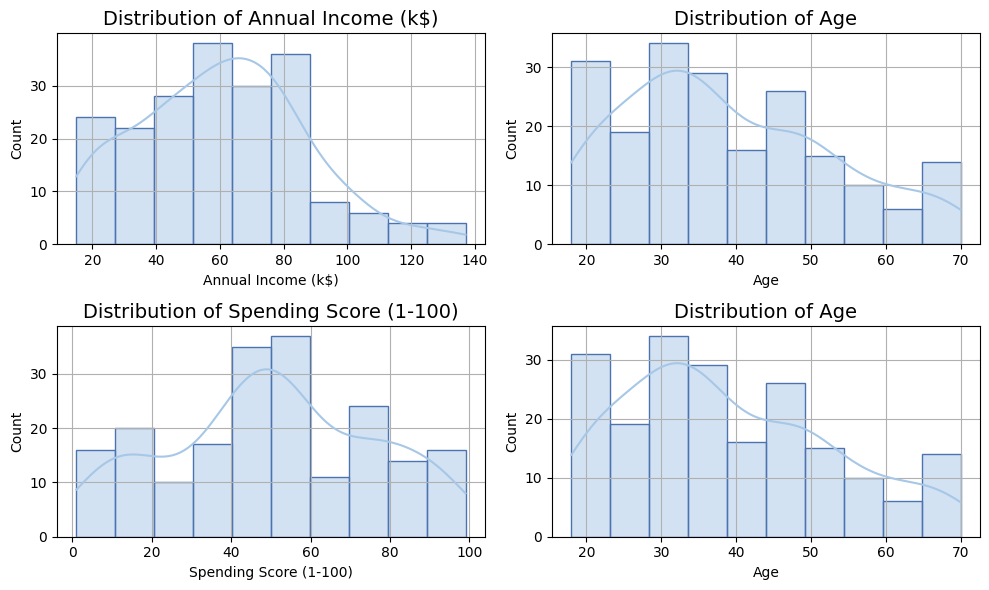

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    'Annual Income (k$)',
    'Age',
    'Spending Score (1-100)',
    'Age'
]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(
        df[col],
        bins=10,
        kde=True,
        color='#A7C7E7',       
        edgecolor='#4C72B0',
        linewidth=1,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].grid(True)

plt.tight_layout()
plt.show()


In [5]:
df_copy = df[["CustomerID","Gender","Age","Annual Income (k$)","Spending Score (1-100)"]]
X = df_copy[["Annual Income (k$)","Spending Score (1-100)"]]

In [6]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


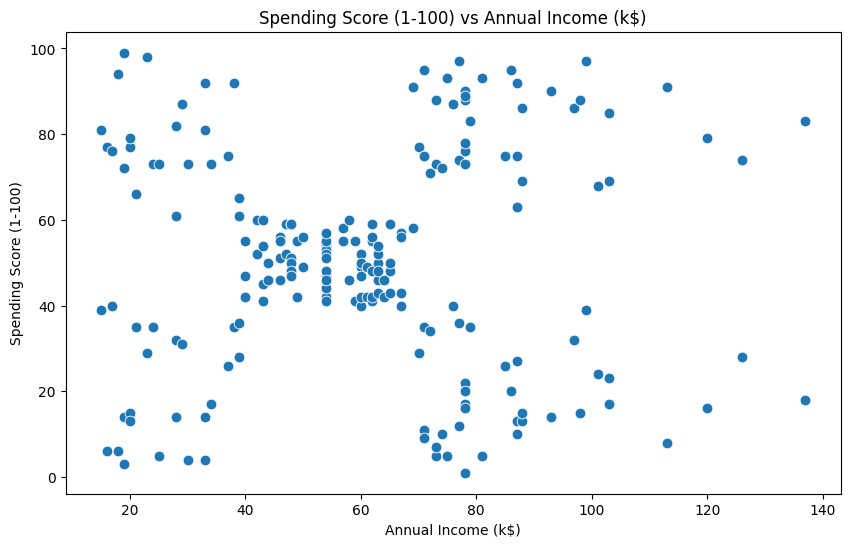

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(x = 'Annual Income (k$)',
                y = 'Spending Score (1-100)',  
                data = X  ,s = 60 )
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)') 
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.show()

In [8]:
#Importing KMeans from sklearn
from sklearn.cluster import KMeans

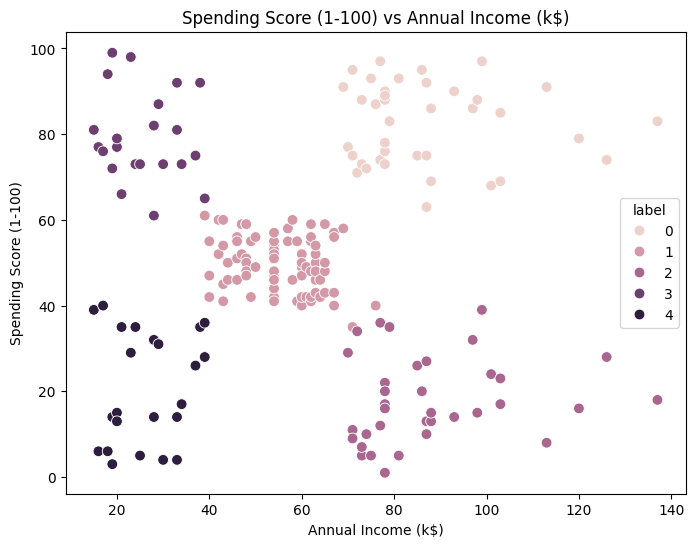

In [10]:
km = KMeans(n_clusters=5)
km.fit(X)
y= km.predict(X)
df_copy["label"] = y

plt.figure(figsize=(8,6))
sns.scatterplot(
                x = 'Annual Income (k$)',
                y = 'Spending Score (1-100)',
                hue="label",  
                # palette=['green','orange','brown'], 
                legend='full',data = df_copy  ,s = 60
                )

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)') 
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.show()

In [11]:
from sklearn.cluster import KMeans

def compute_wcss(X, k_range=range(1, 11), random_state=42):

    wcss = []
    
    for k in k_range:
        km = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=random_state
        )
        km.fit(X)
        wcss.append(km.inertia_)
    
    return wcss

import matplotlib.pyplot as plt
import numpy as np

def plot_elbow_curve(k_range, wcss):

    plt.figure(figsize=(8, 6))
    
    plt.plot(
        k_range,
        wcss,
        marker='o',
        linestyle='-',
        linewidth=2,
        color='#E74C3C'
    )
    
    plt.xticks(k_range)
    plt.xlabel('Number of Clusters (K)', fontsize=12)
    plt.ylabel('WCSS (Inertia)', fontsize=12)
    plt.title('Elbow Method for Optimal K', fontsize=16)
    plt.grid(True)
    
    plt.show()


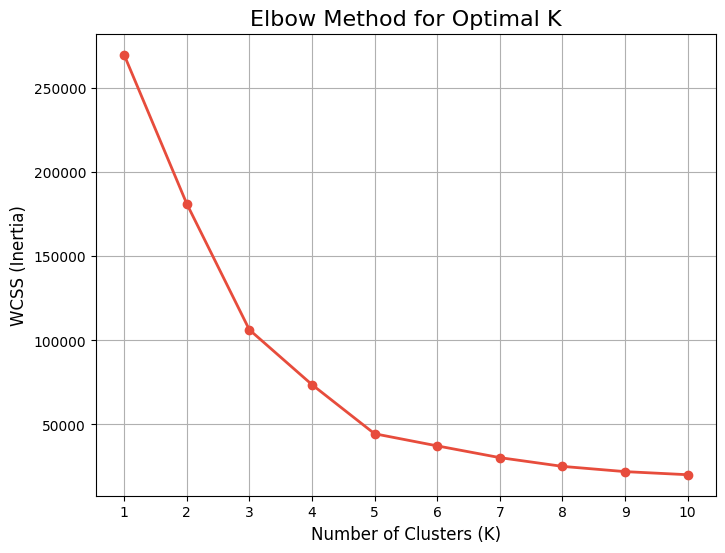

In [12]:
k_range = range(1, 11)
wcss = compute_wcss(X, k_range)
plot_elbow_curve(k_range, wcss)


In [13]:
df_copy = df[["CustomerID","Gender","Age","Annual Income (k$)","Spending Score (1-100)"]]
X = df_copy[["Age", "Annual Income (k$)","Spending Score (1-100)"]]

km = KMeans(n_clusters=3)
km.fit(X)
y= km.predict(X)
df_copy["label"] = y

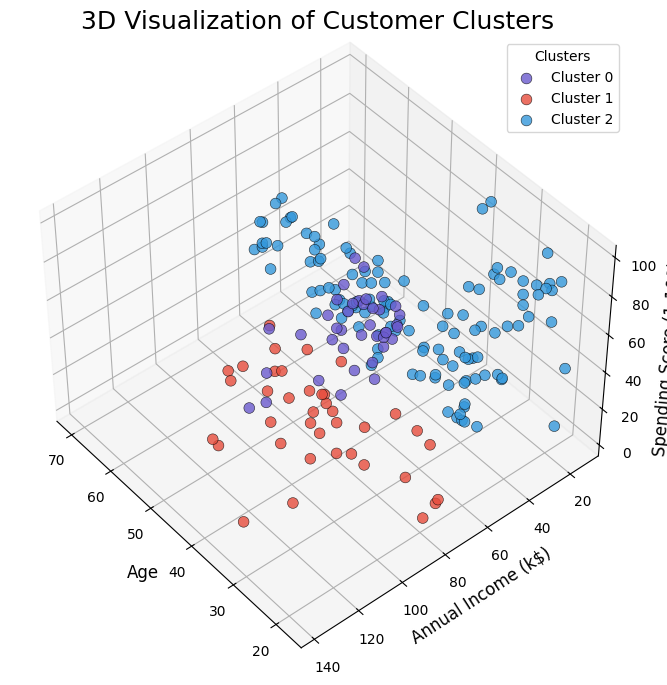

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['#6A5ACD', '#E74C3C', '#3498DB', '#2ECC71', '#F1C40F']

for label, color in zip(sorted(df_copy.label.unique()), colors):
    ax.scatter(
        df_copy.loc[df_copy.label == label, 'Age'],
        df_copy.loc[df_copy.label == label, 'Annual Income (k$)'],
        df_copy.loc[df_copy.label == label, 'Spending Score (1-100)'],
        c=color,
        s=60,
        alpha=0.8,
        edgecolor='black',
        linewidth=0.4,
        label=f'Cluster {label}'
    )


ax.view_init(elev=45, azim=140)


ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Annual Income (k$)', fontsize=12)
ax.set_zlabel('Spending Score (1-100)', fontsize=12)

ax.set_title('3D Visualization of Customer Clusters', fontsize=18)
ax.legend(title='Clusters')

plt.show()


In [34]:
for label in sorted(df_copy['label'].unique()):
    cust = df_copy[df_copy['label'] == label]
    print(f'Number of customers in group {label} = {len(cust)}')
    print('They are -', cust['CustomerID'].values)
    print('-' * 60)


Number of customers in group 0 = 123
They are - [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123]
------------------------------------------------------------
Number of customers in group 1 = 39
They are - [124 126 128 130 132 134 136 138 140 142 144 146 148 150 152 154 156 158
 160 162 164 166 168 170 172 174 176 178 180 182 184 186 188 190 192 194
 196 198 200]
------------------------------------------------------------
Number of customers in group 2 = 38
They are - [125 127 129 131 133 135 137 139 141 143 145 147 149 151 153 155 157 159
 16

In [35]:
summary = (
    df_copy.groupby('label')['CustomerID']
       .agg(['count', list])
)

summary


,count,list
label,,
0,123,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,39,"[124, 126, 128, 130, 132, 134, 136, 138, 140, ..."
2,38,"[125, 127, 129, 131, 133, 135, 137, 139, 141, ..."
